# import packages

In [7]:
from seaborn import color_palette
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import glob

# set working directory

In [8]:
data_dir = r"C:/Users/l_v_v/Documents/GitHub/time_series_curuai/datasets/Parameters Time series/merged_df"

# standard plotting functions

In [9]:
# Configure matplotlib visualization parameters for consistency across all plots
plt.rcParams['font.size'] = 11  # Base font size
plt.rcParams['axes.labelsize'] = 14  # Axis label font size
plt.rcParams['axes.titlesize'] = 14  # Plot title font size
plt.rcParams['xtick.labelsize'] = 14  # X-axis tick label size
plt.rcParams['ytick.labelsize'] = 14  # Y-axis tick label size
plt.rcParams['legend.fontsize'] = 12  # Legend font size

In [10]:
def prepare_time_series_plot(paths_var, paths_trend, dict_var, data_dir, color_palette=None):
    """Read paired time-series and trend CSVs and plot them efficiently.

    Parameters
    - paths_var: list of CSV filepaths containing time series (must contain 'time_start' and variables)
    - paths_trend: list of CSV filepaths with trend info; must contain a 'variable' column and a 'trend' column
    - dict_var: mapping variable -> {'title':..., 'label':...}
    - data_dir: base directory (used only for path context)
    - color_palette: optional list of colors for water periods
    """

    # 1. Define Fixed Color Mapping for Water Periods
    if color_palette is None:
        # Standard colors: Red, Orange, Blue, Green
        color_vals = ['#d62728', '#ff7f0e', '#1f77b4', '#2ca02c']
    else:
        color_vals = color_palette
    
    # Map specific periods to specific colors
    period_order = ["R", "HW", "F", "LW"]
    fixed_colors = {p: color_vals[i % len(color_vals)] for i, p in enumerate(period_order)}

    for p_var, p_trend in zip(paths_var, paths_trend):
        df = pd.read_csv(p_var, parse_dates=['time_start']).sort_values('time_start')

        # Load trends robustly
        try:
            df_trend = pd.read_csv(p_trend)
        except Exception:
            df_trend = pd.read_csv(p_trend, encoding='utf-8', engine='python')

        if 'Unnamed: 0' in df_trend.columns:
            df_trend = df_trend.drop(columns=['Unnamed: 0'])
        if 'variable' in df_trend.columns:
            df_trend = df_trend.set_index('variable')

        # Identify the water period from the filename to filter the data
        w_p = os.path.basename(paths_trend[0]).split("_")[-1].split(".")[0]
        
        # Filter dataframe for the specific water period
        if 'water_period' in df.columns:
            df = df.loc[df['water_period'] == w_p].copy()
            df = df.reset_index(drop=True)
        
        print(f"Plotting for period: {w_p} | Records: {len(df)}")

        # Use keys from dict_var to ensure ALL variables are plotted
        axes = list(dict_var.keys())

        if not axes:
            print("No variables found in dictionary.")
            continue

        fig, axs = plt.subplots(len(axes), 1, figsize=(12, 4 * len(axes)), squeeze=False)

        for i, var in enumerate(axes):
            ax = axs[i, 0]

            if var not in df.columns:
                ax.text(0.5, 0.5, f"{var} not in data columns", ha='center')
                continue

            # Determine color based on the fixed mapping
            plot_color = fixed_colors.get(w_p, 'black') 

            # --- Plotting Logic ---
            # Set defaults for trend calculation
            series = df[var]
            x = df['time_start']
            
            if ("anthropogenic_km2" in var) or ("natural_km2" in var):
                # Logic for area variables (using drop_duplicates)
                drop_duplicates = df.drop_duplicates(subset=[var])
                series = drop_duplicates[var]
                x = drop_duplicates['time_start']
                
                ax.plot(x, series, color='gray', linestyle='-.', linewidth=1, alpha=0.6)
                ax.plot(x, series, marker='o', linestyle='none', markersize=6, 
                        color=plot_color, alpha=0.8, label=f"{w_p} Yearly Estimates")
            else:
                # Logic for standard variables
                ax.plot(x, series, color='gray', linestyle='-.', linewidth=1, alpha=0.6)
                ax.plot(x, series, marker='o', linestyle='none', markersize=6, 
                        color=plot_color, alpha=0.8, label=str(w_p))

            # Prepare for trend line
            x_ord = x.map(pd.Timestamp.toordinal)
            valid = series.notna() & x_ord.notna()

            # --- Trend Line Calculation ---
            m, b = np.nan, np.nan
            if valid.sum() > 1:
                try:
                    m, b = np.polyfit(x_ord[valid], series[valid], 1)
                    ax.plot(x, m * x_ord + b, color='black', linestyle='--', linewidth=1)
                except Exception as e:
                    print(f"Could not fit line for {var}: {e}")

            # --- Styling ---
            ax.set_xlabel('Date')
            ax.set_ylabel(dict_var.get(var, {}).get('label', var))
            ax.set_title(dict_var.get(var, {}).get('title', var) + ' vs Time')

            # --- Annotation Logic (Fixed) ---
            # 1. Retrieve trend text if available
            trend_text = ''
            if var in df_trend.index:
                try:
                    val = df_trend.loc[var, 'trend']
                    # Handle case where val might be NaN or not string
                    if pd.notna(val):
                        trend_text = str(val)
                except Exception:
                    trend_text = ''
            
            # 2. Build the final annotation string
            anno_parts = []
            if not np.isnan(m):
                anno_parts.append(f"y = {m:.3f}x + {b:.3f}")
            if trend_text:
                anno_parts.append(trend_text)
            
            # 3. Display if there is anything to show
            if anno_parts:
                final_text = "\n".join(anno_parts)
                ax.annotate(final_text, 
                            xy=(0.75, 1.01), xycoords='axes fraction')
            ax.annotate(f"n = {int(series.count())}", xy=(0.75, 0.95), xycoords='axes fraction')

            ax.legend(loc='upper left')

        plt.tight_layout()
        plt.show()
        plt.close(fig)

In [11]:
dict_var = {
    "TSS_mean":{"title": "TSS", 'label': "TSS (mg/L)"},
    "area_km2": {"title": "Water Surface Area", 'label': "Area (km$^2$)"},
    "precipitation": {"title": "Precipitation", 'label': "Accumulated Precipitation\n(total mm/Hidrological Period)"},
    'u_wind': {"title": "Eastward Wind Speed", 'label': "Eastward Mean Wind Speed\n(m/s)"},
    "v_wind": {"title": "Northward Wind Speed", 'label': "Northward Mean Wind Speed\n(m/s)"},
    'anthropogenic_km2': {"title": "Anthropic Area", 'label': "Anthropic Area (km²)"},
    'natural_km2': {"title": "Natural Area", 'label': "Natural Area (km²)"},
    "mean_discharge": {"title": "Discharge", 'label': "Mean Discharge (m$^3$/s)"}
}


regional

R
Plotting for period: R | Records: 34


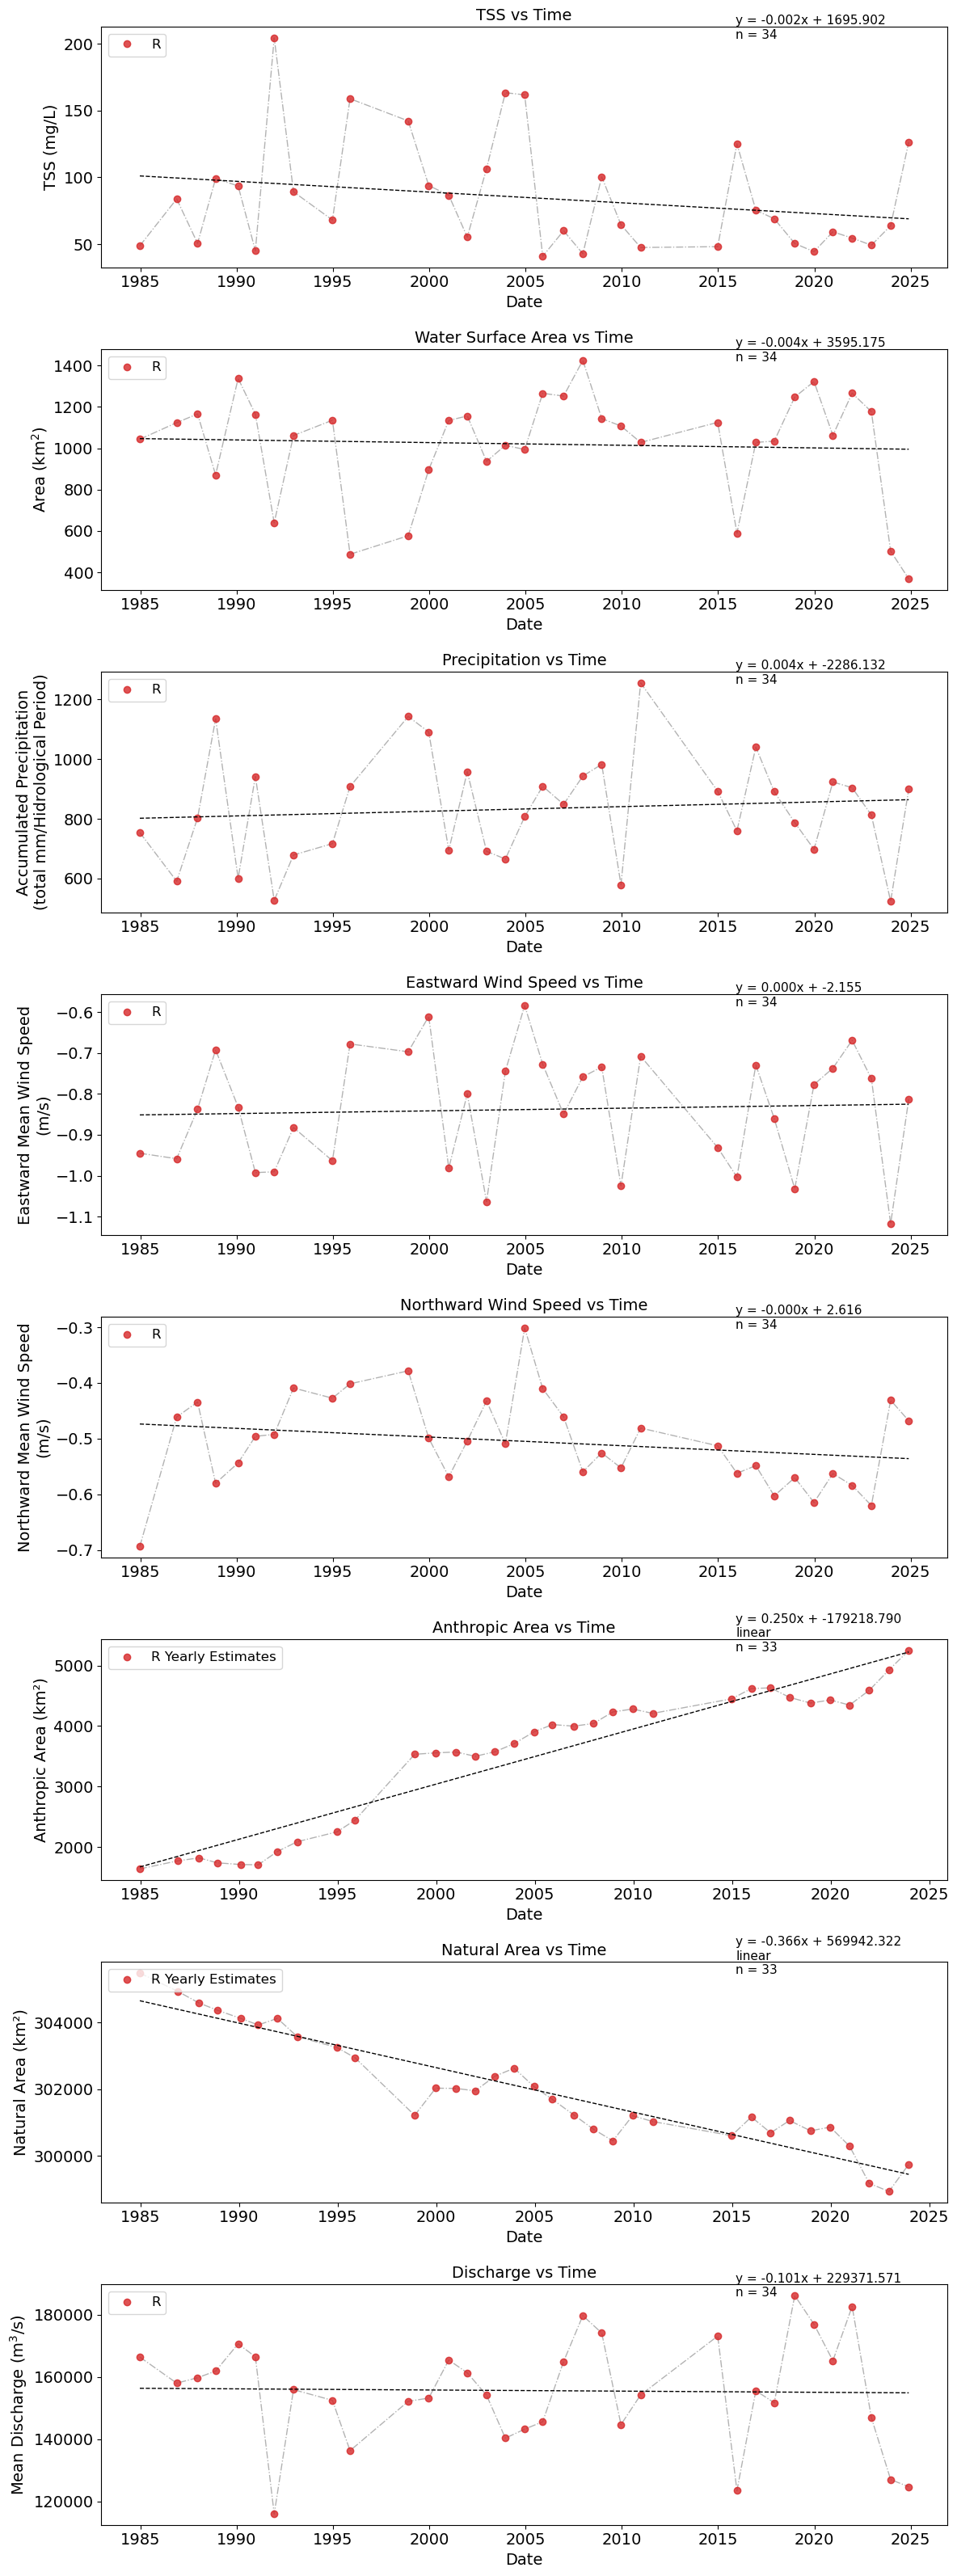


HW
Plotting for period: HW | Records: 35


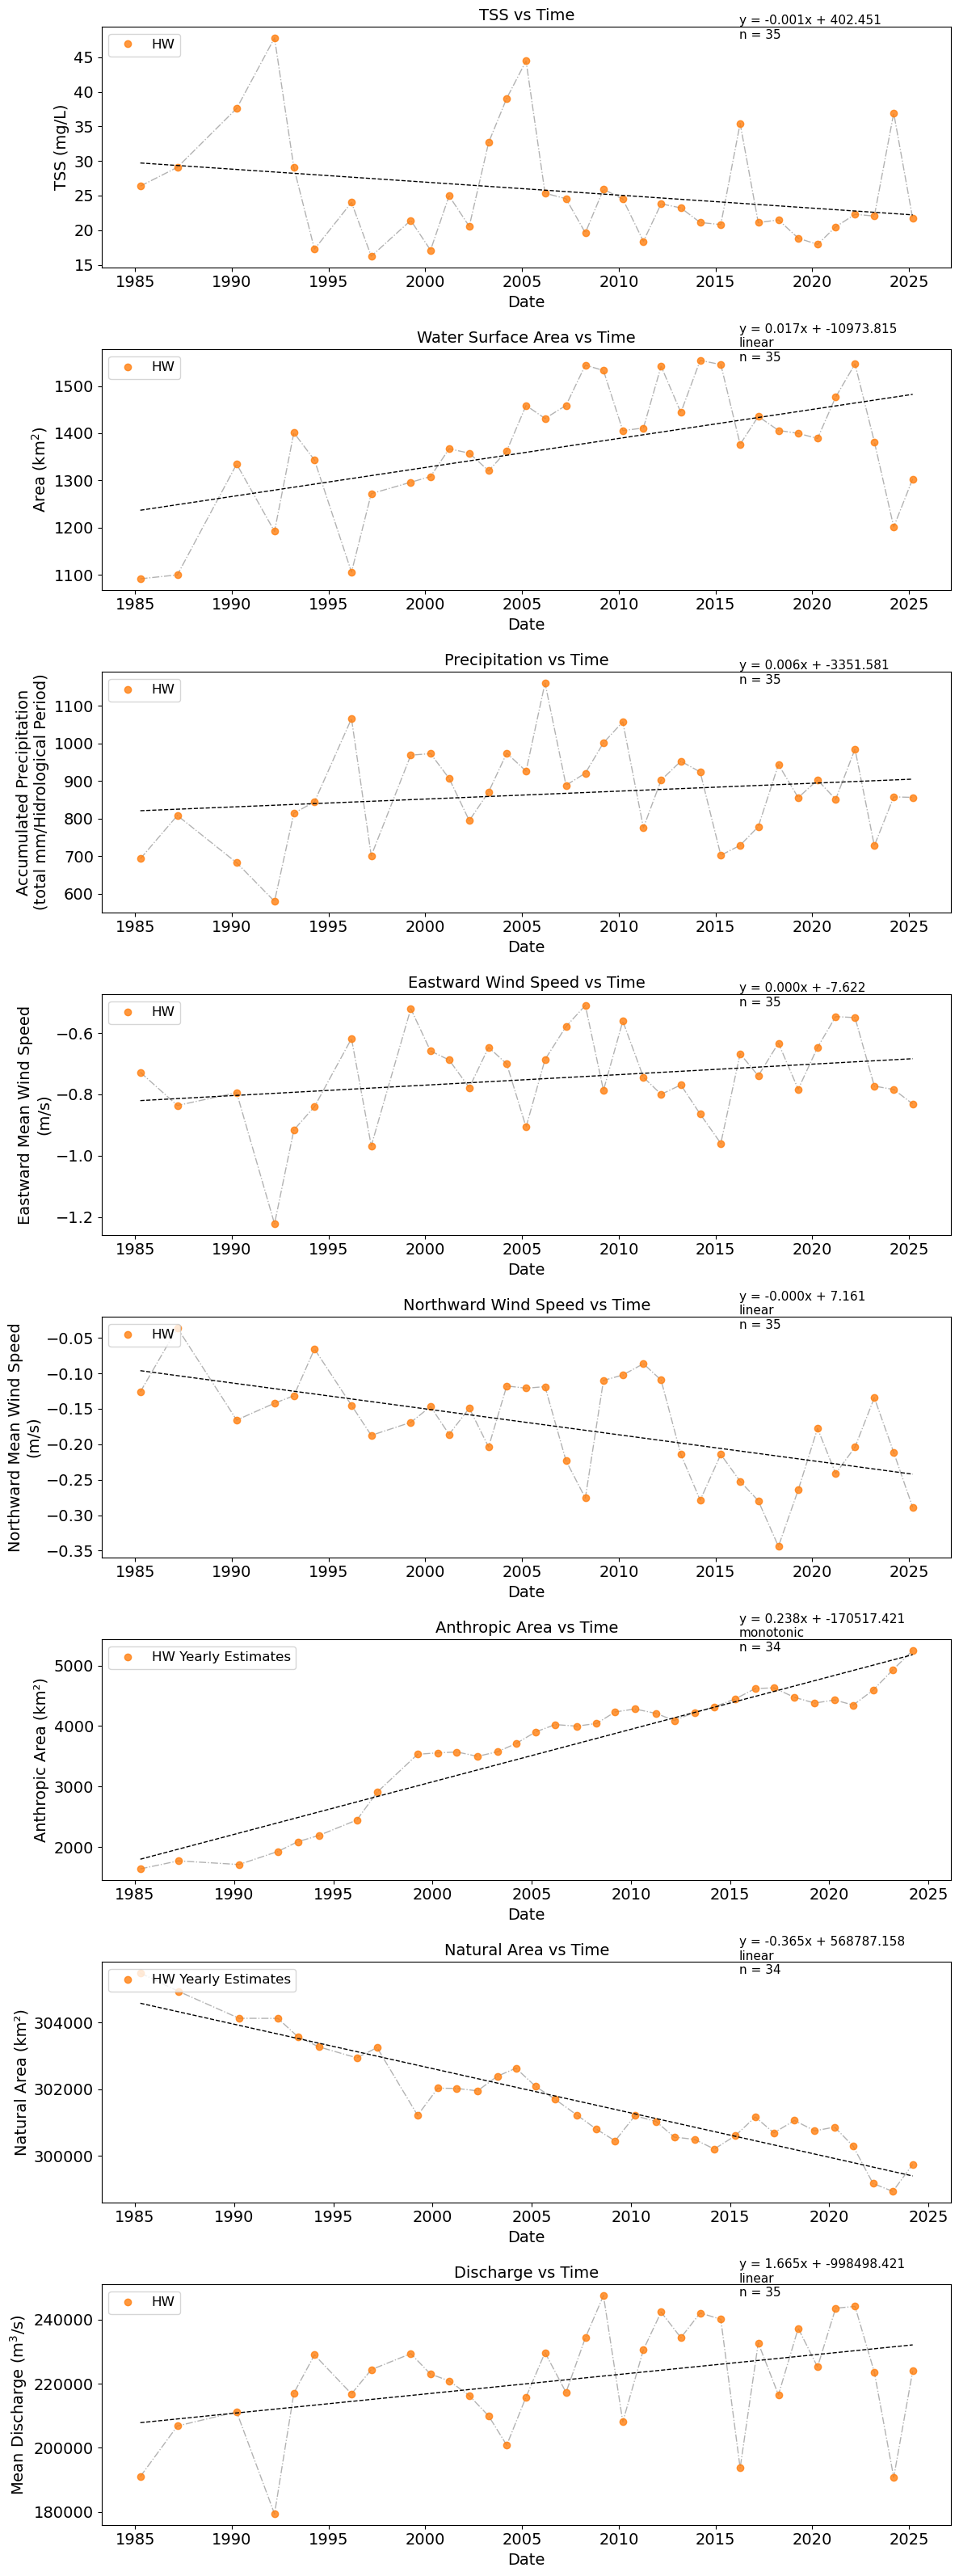


F
Plotting for period: F | Records: 41


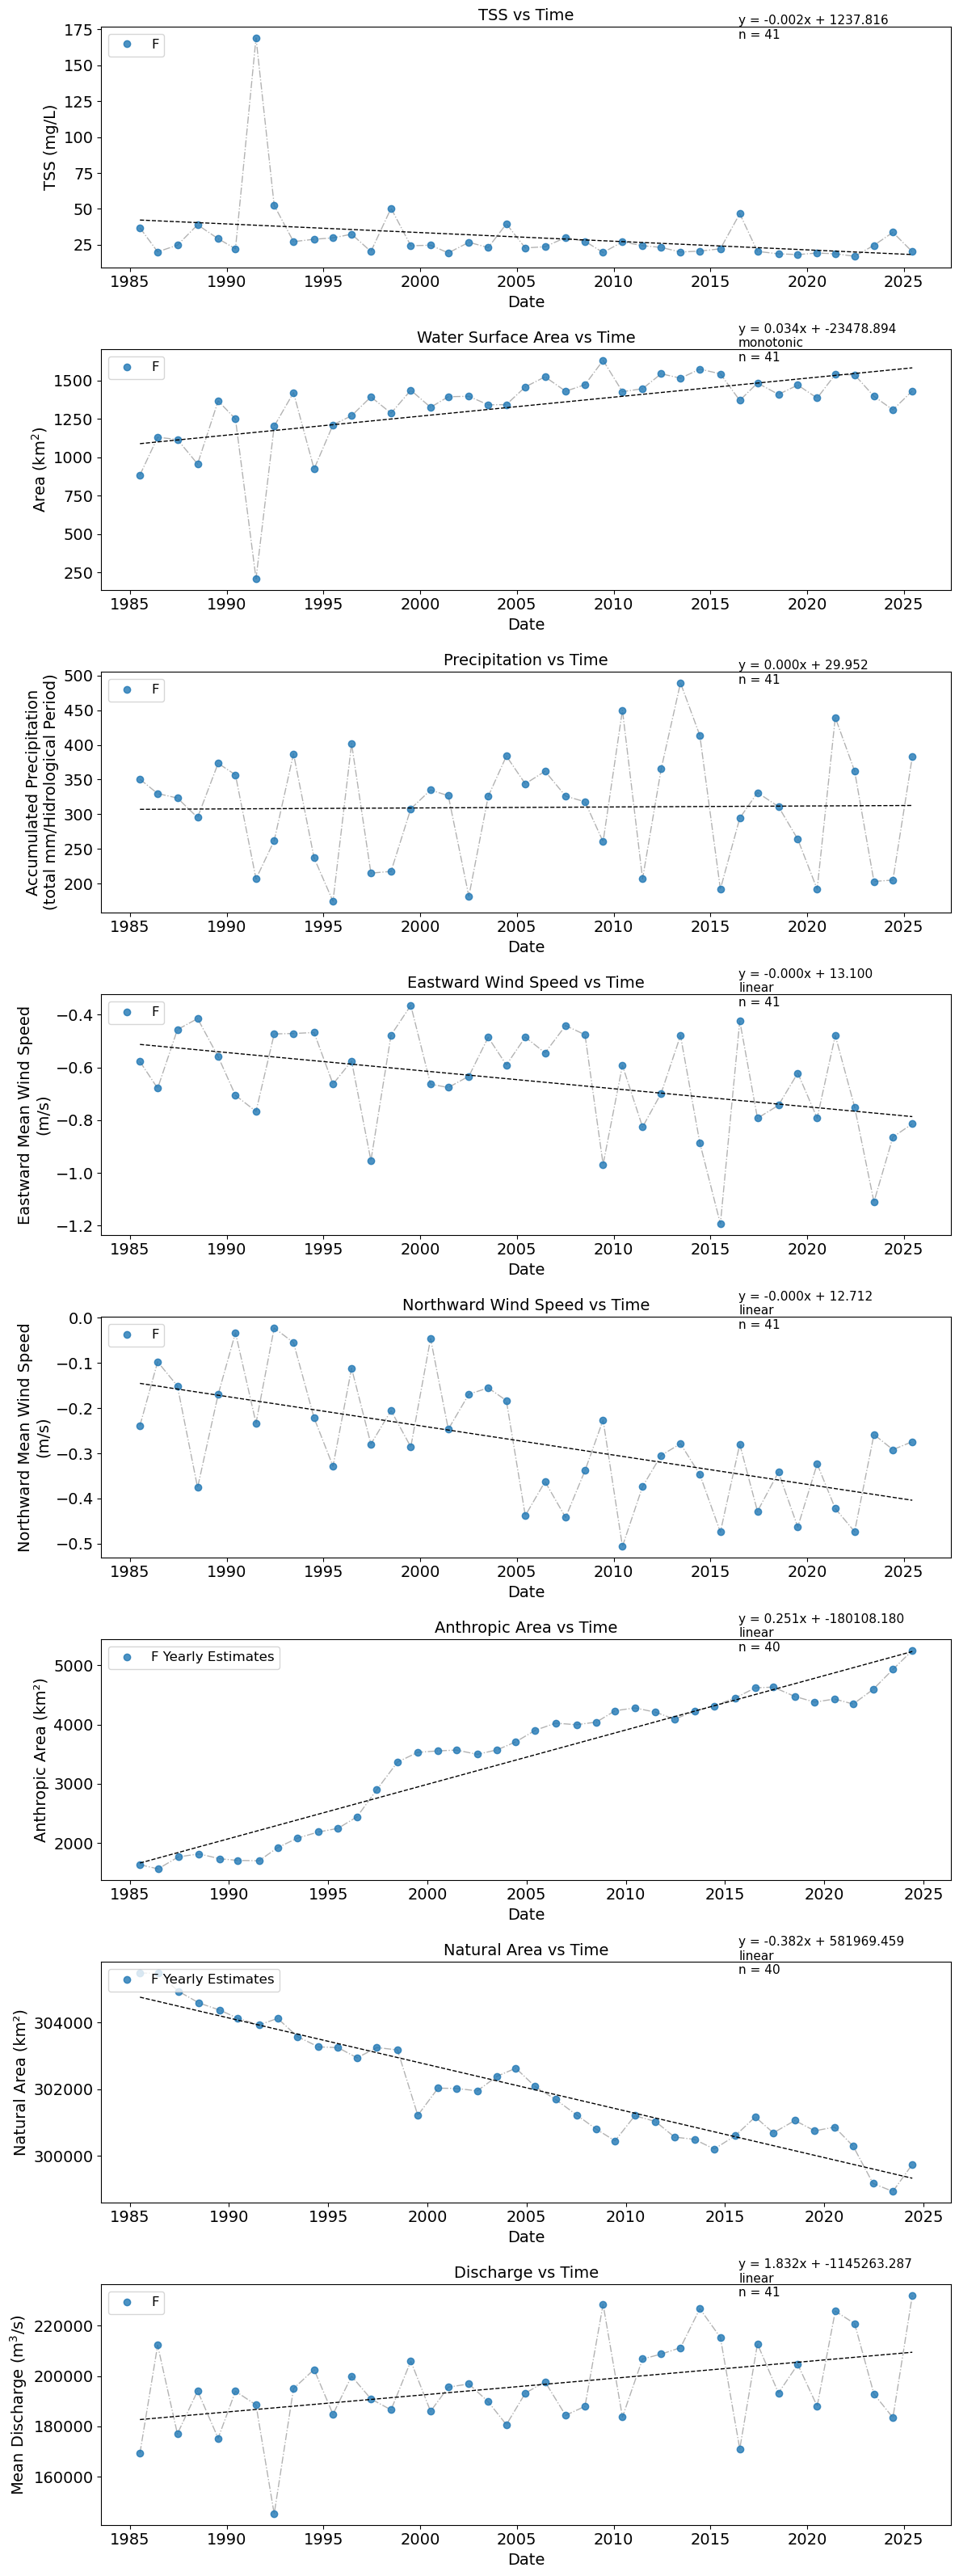


LW
Plotting for period: LW | Records: 37


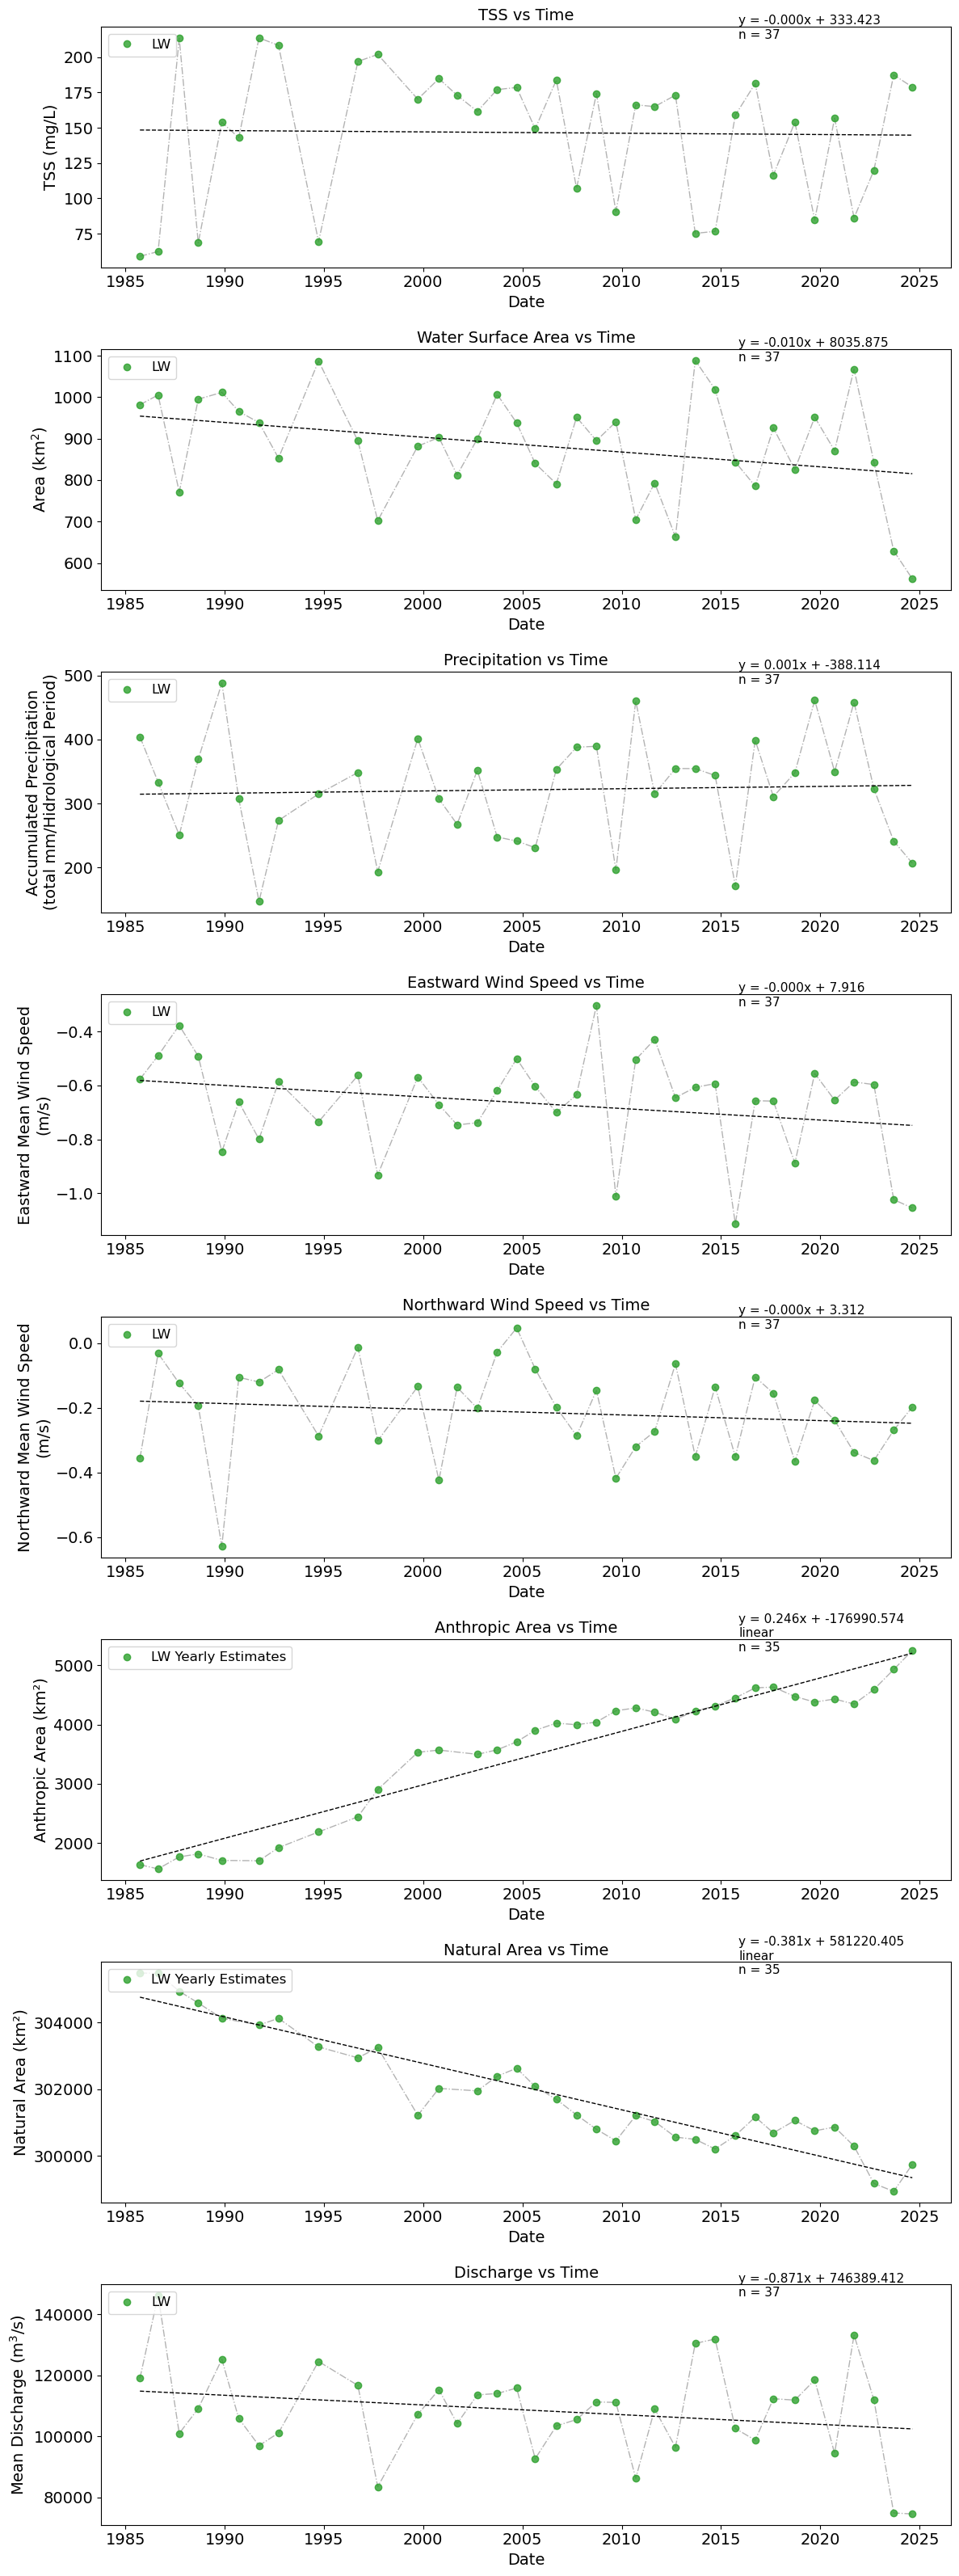


local

R
Plotting for period: R | Records: 34


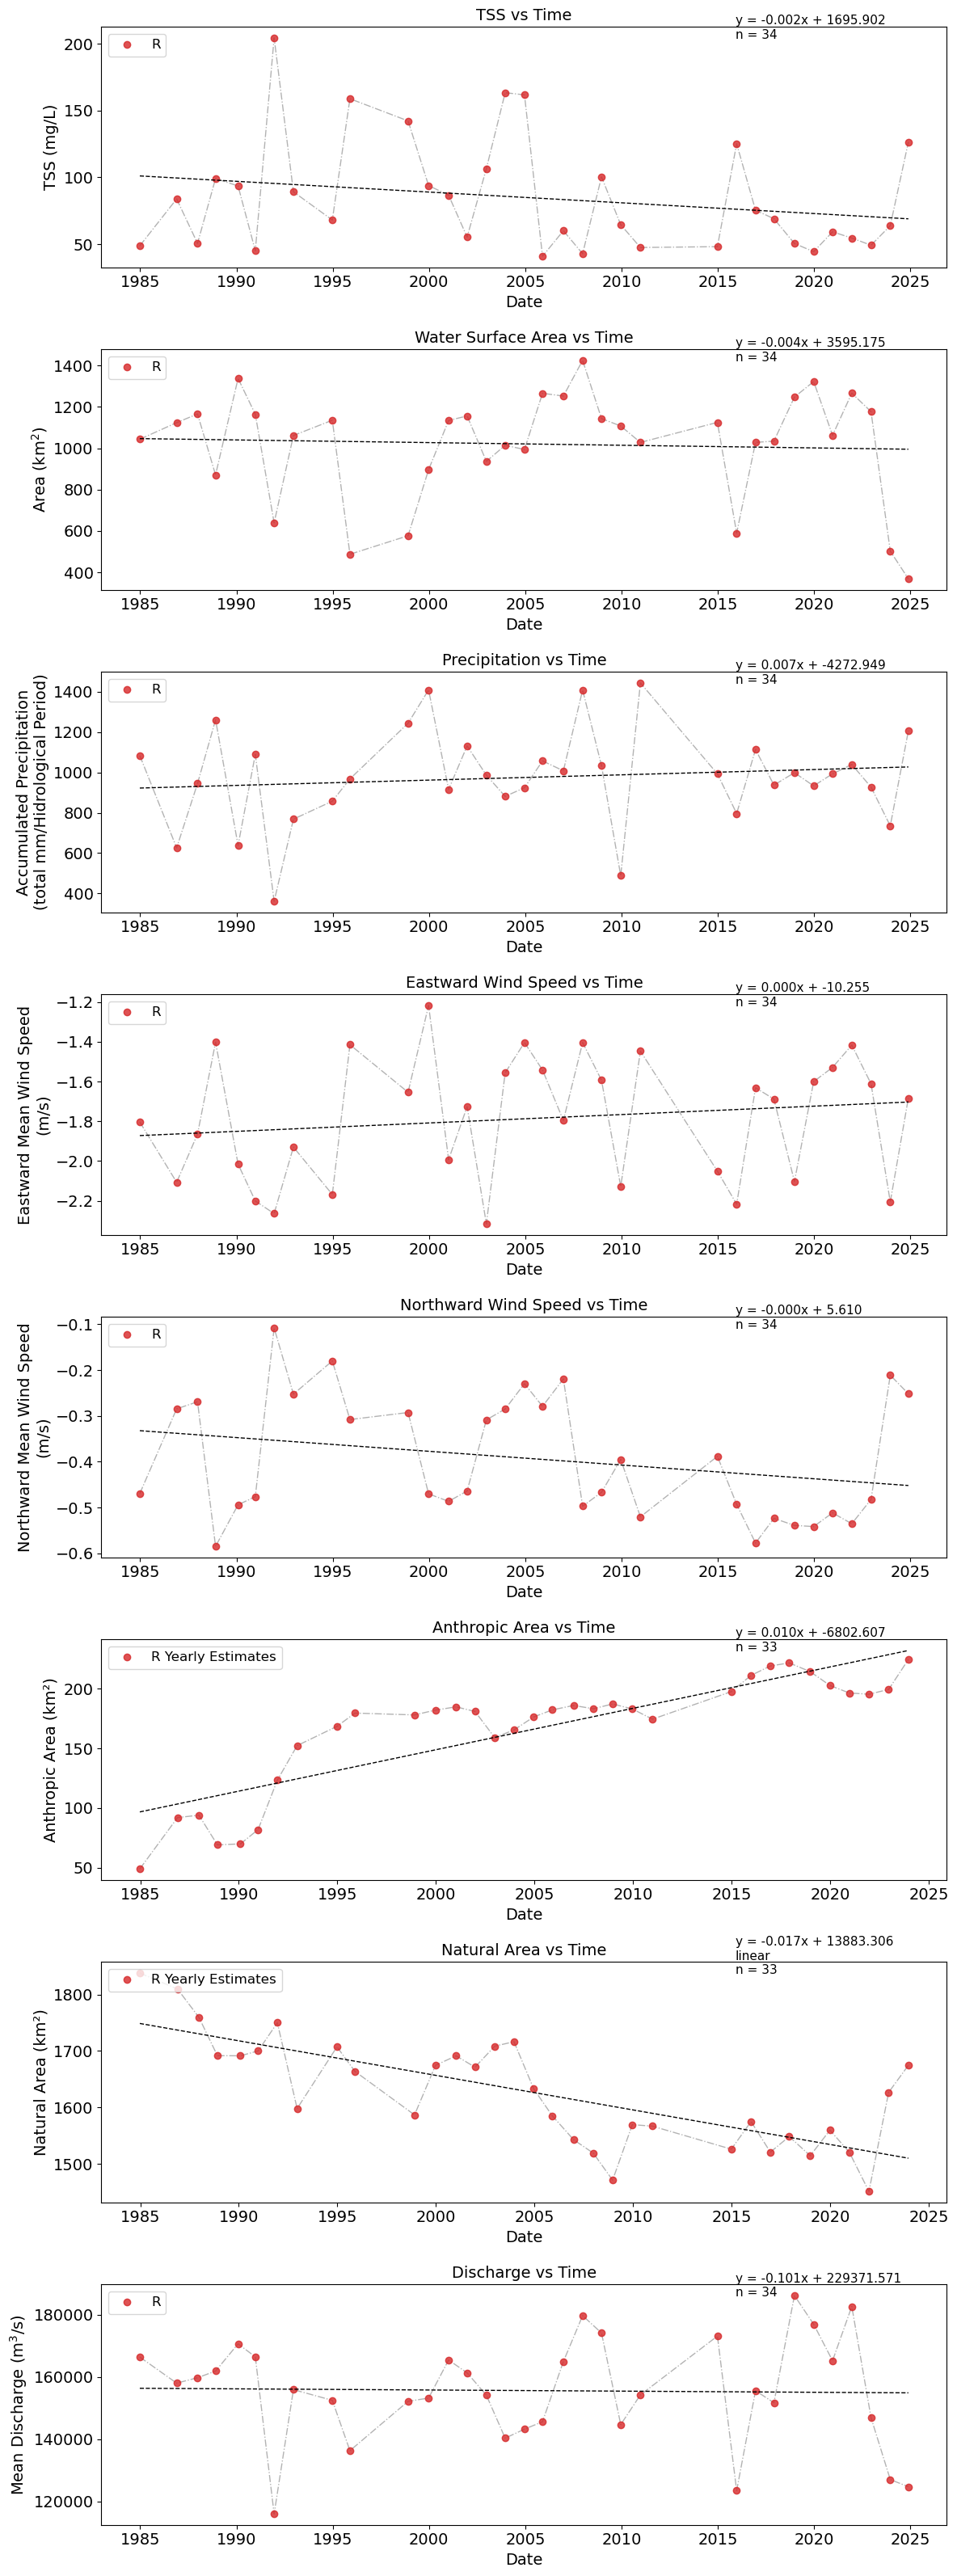


HW
Plotting for period: HW | Records: 35


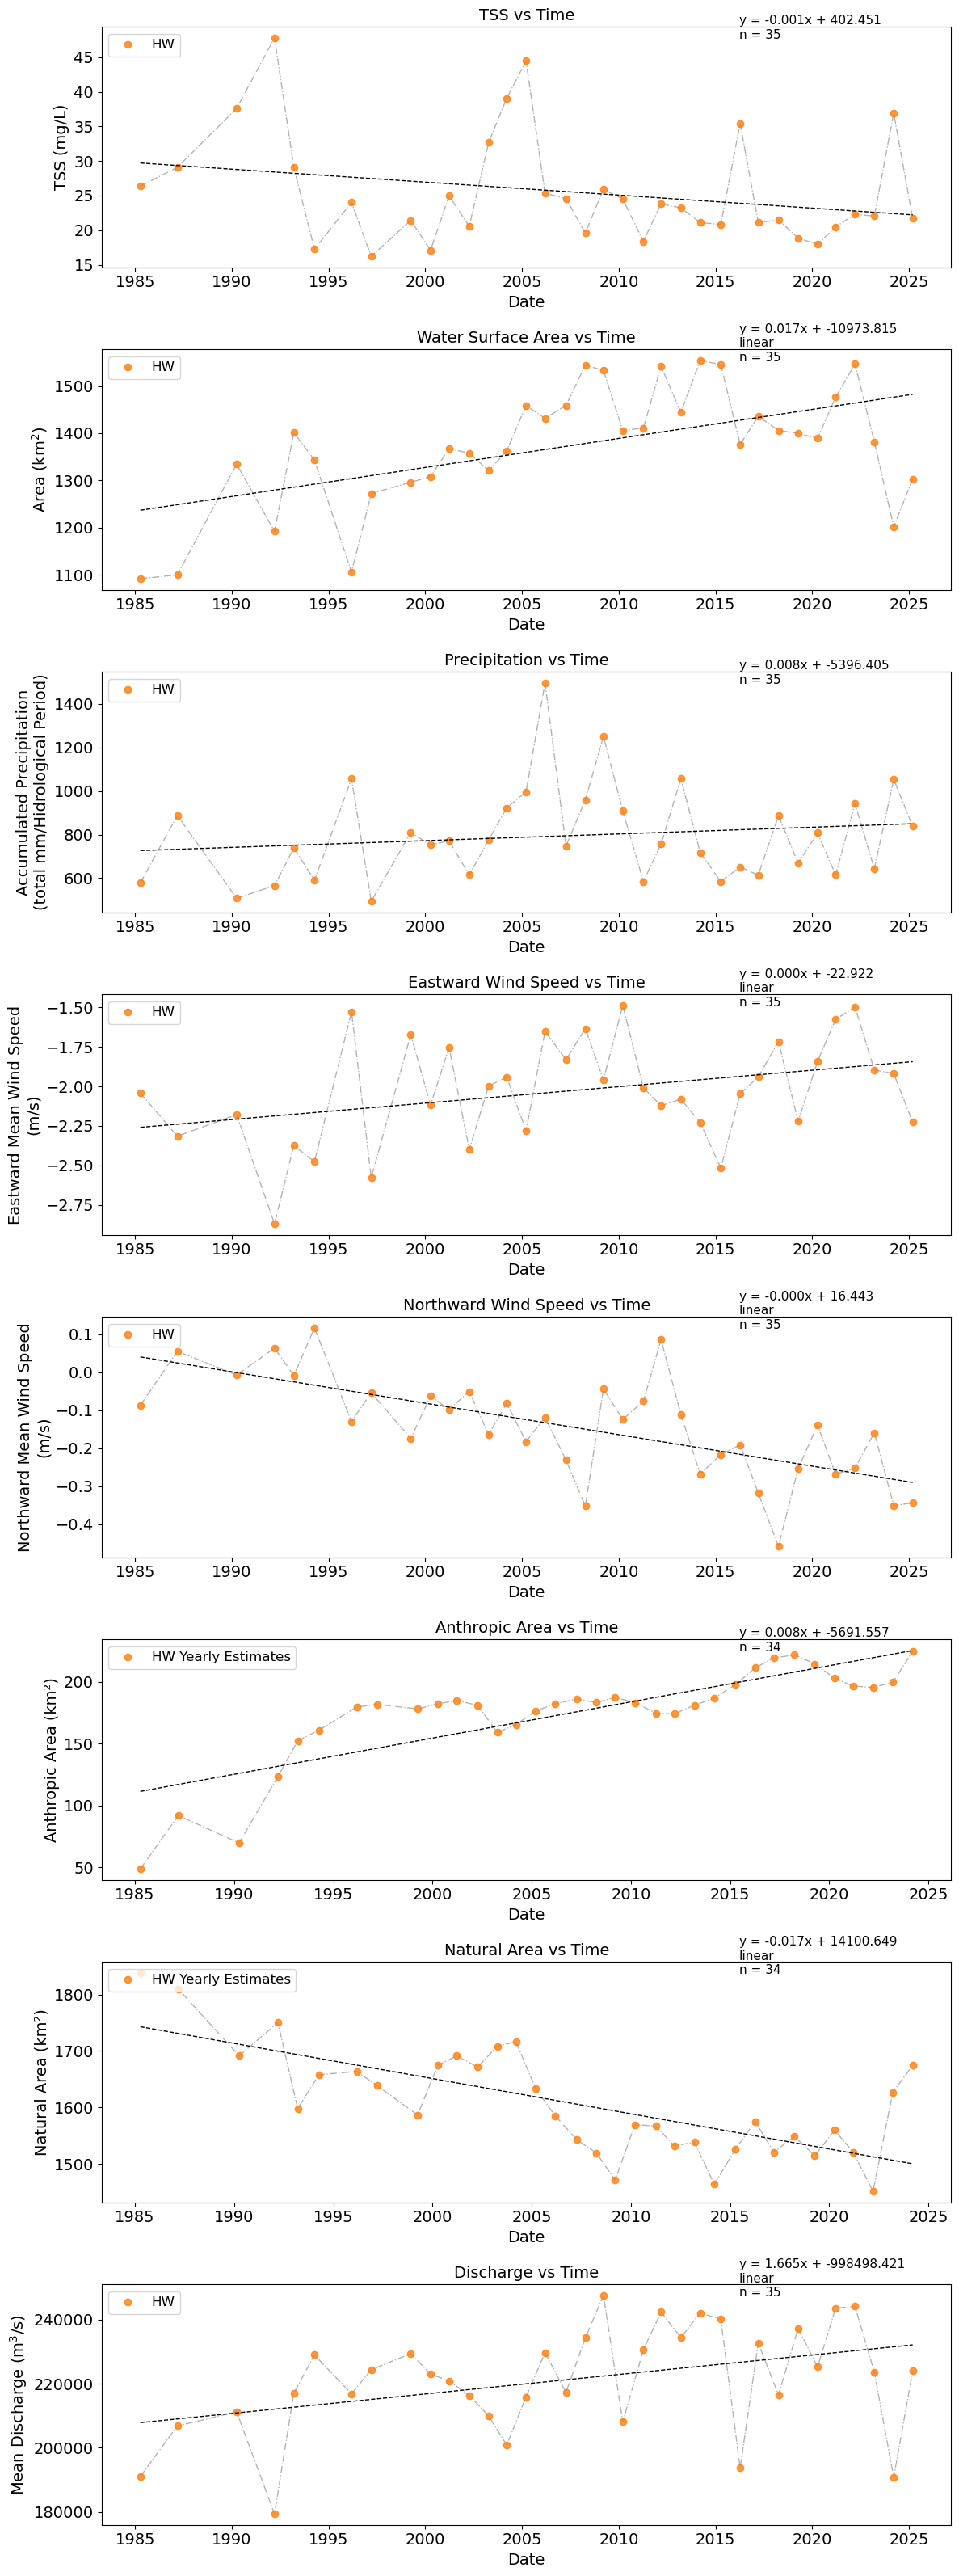


F
Plotting for period: F | Records: 41


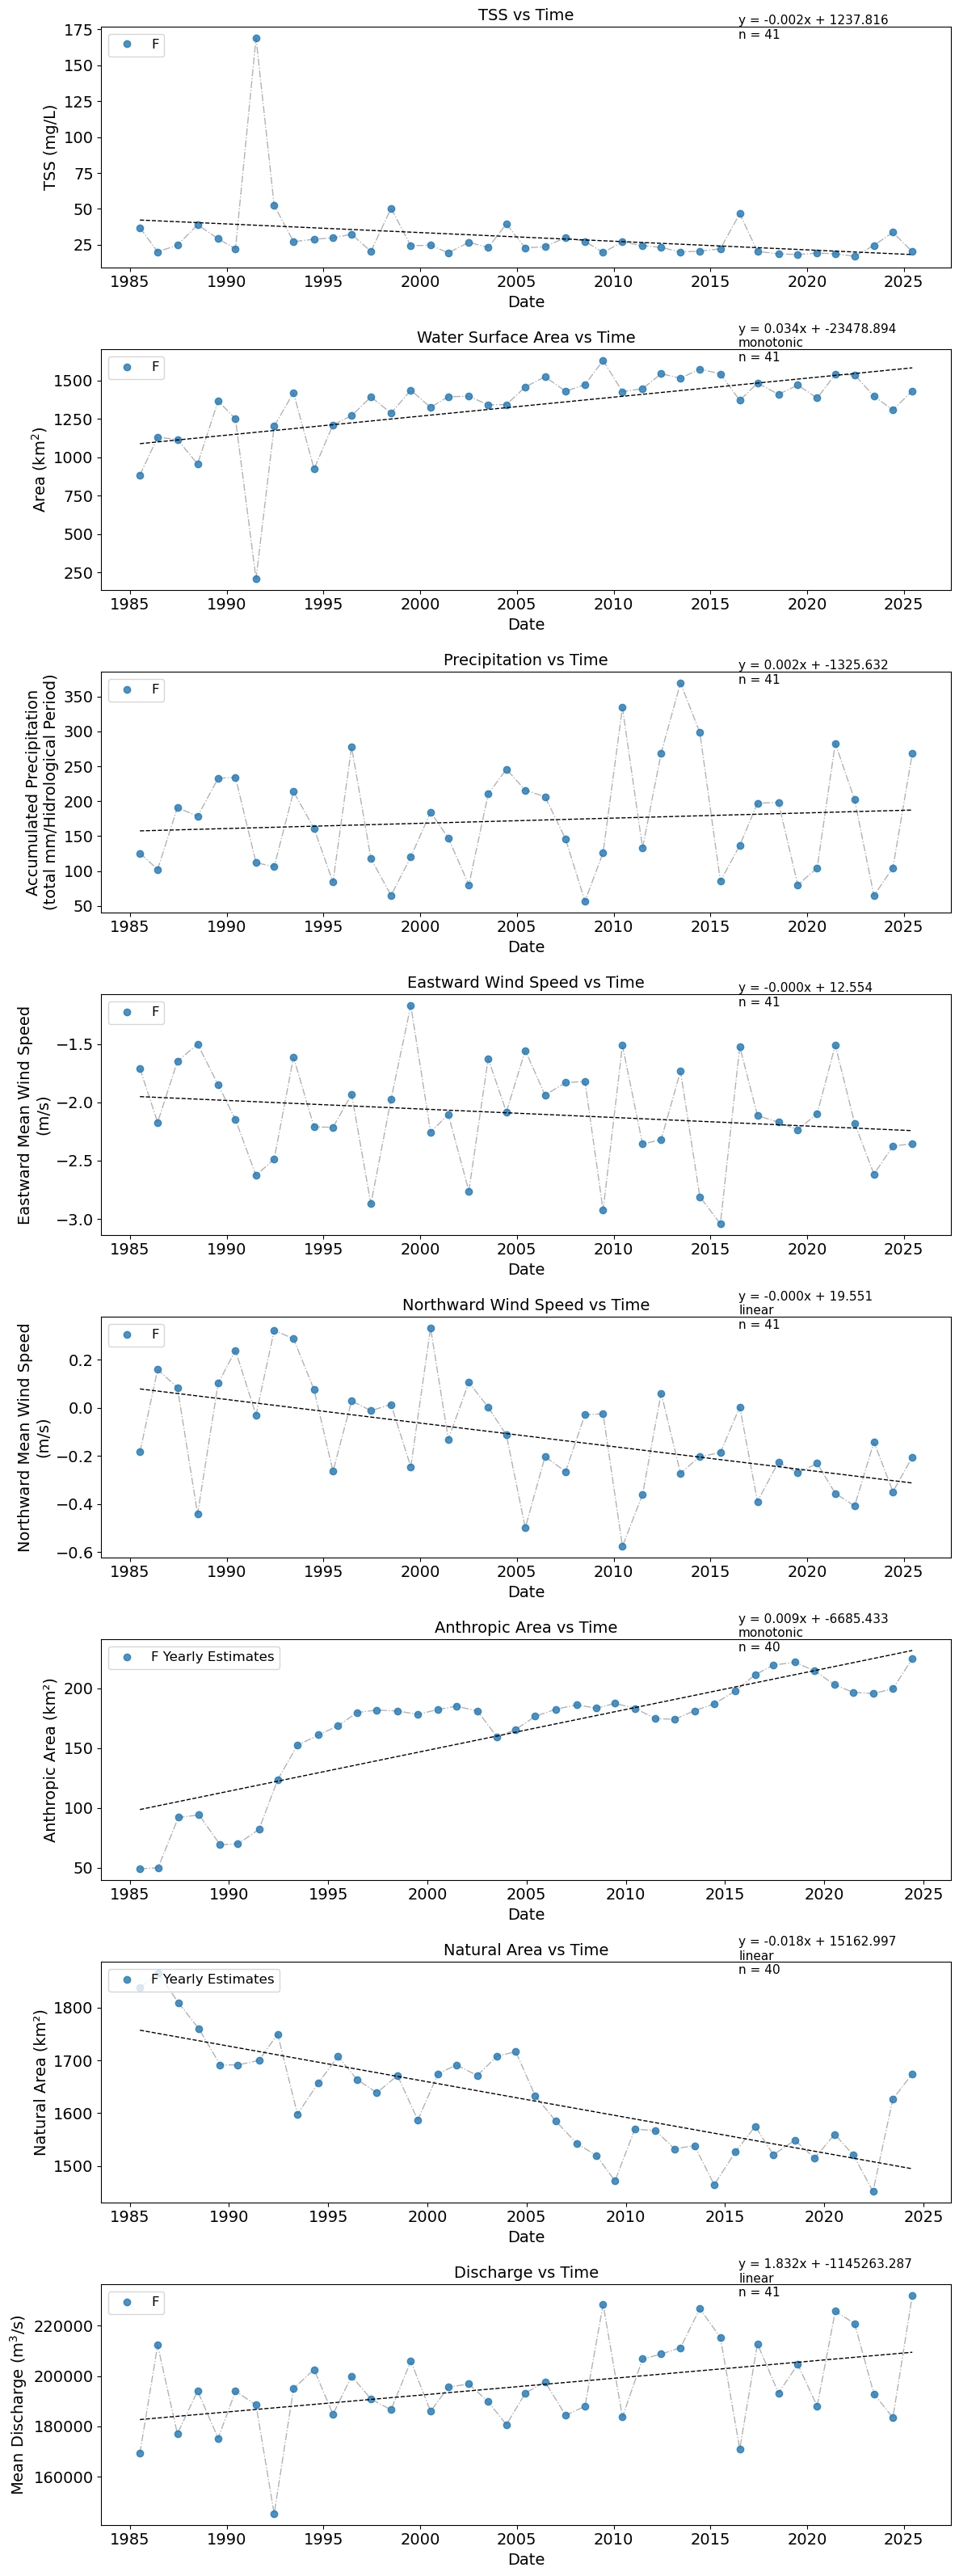


LW
Plotting for period: LW | Records: 37


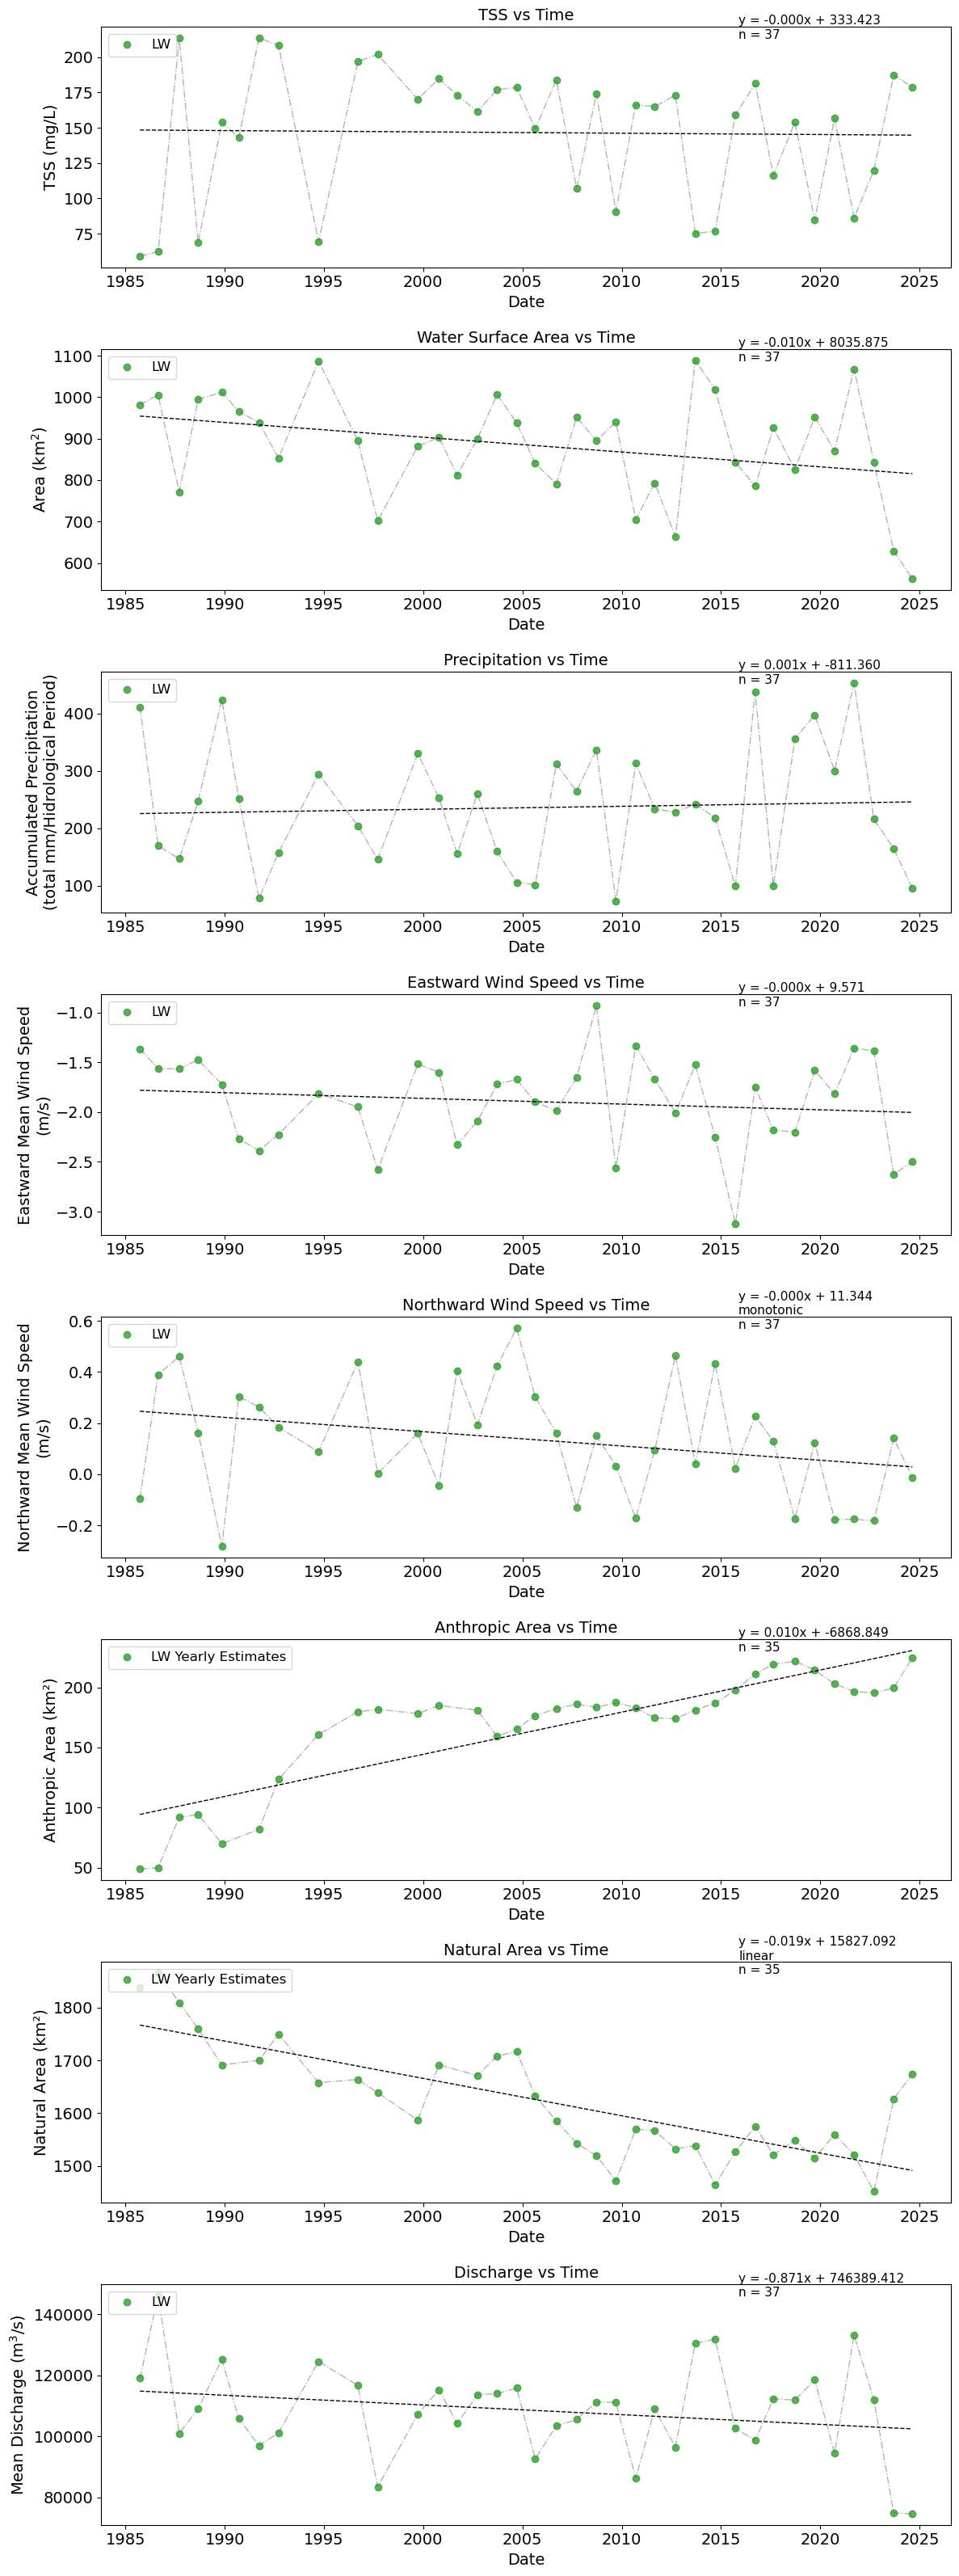

In [12]:
# Prepare and call plotting helper
watersheds = ["regional","local"]
water_periods = ["R","HW","F","LW"]
for watershed in watersheds:
    # paths_var = sorted(glob.glob(os.path.join(data_dir,f"{watershed}*/filled*.csv")))
    paths_var = sorted(glob.glob(f"C:/Users/l_v_v/Documents/GitHub/time_series_curuai/datasets/Parameters Time series/merged_df/*merged*{watershed}*.csv"))
    print()
    print(watershed)
    # print(paths_var)
    for wp in water_periods:
        paths_trend = sorted(glob.glob(os.path.join(data_dir,f"{watershed}*Watershed/trends/*{wp}.csv")))
        print()
        print(wp)
        # print()
        # Call the cleaned, efficient plotting function. It will loop over paired files and show figures.
        prepare_time_series_plot(paths_var, paths_trend, dict_var, data_dir)